<a href="https://colab.research.google.com/github/idoyeon156-cloud/2026_Fall_ML/blob/main/2026_Fall_semester_ML_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 생성된 데이터: 처음 10개 ===


,x (shared),y_A (linear generation),lambda_B (Poisson mean),y_B (Poisson generation)
0,0.274,5.226,4.701,2
1,-0.460,3.080,1.082,0
2,-0.918,1.769,0.433,1
3,-0.967,2.137,0.393,0
4,0.627,5.362,9.517,9
5,0.826,5.313,14.169,14
6,0.213,4.998,4.164,5
7,0.459,3.974,6.807,5
8,0.087,4.068,3.237,1
9,0.870,6.073,15.491,18


Dataset A의 y 범위: 1.093 ~ 6.716
Dataset B의 y 범위: 0 ~ 32

=== 실제 데이터 생성 계수 ===
Dataset A: beta0 = 4.0, beta = 2.0, sigma = 0.5
Dataset B: beta0 = 1.0, beta = 2.0

=== 네 가지 피팅 결과 ===


,Dataset,Fitted model,Estimated beta0,Estimated beta,Test MAE,Test RMSE,Negative predictions
0,A,Linear,3.975,2.007,0.394,0.484,0
1,A,Poisson,1.336,0.510,0.395,0.502,0
2,B,Linear,4.796,8.074,2.652,3.774,15
3,B,Poisson,0.925,2.060,1.809,2.665,0


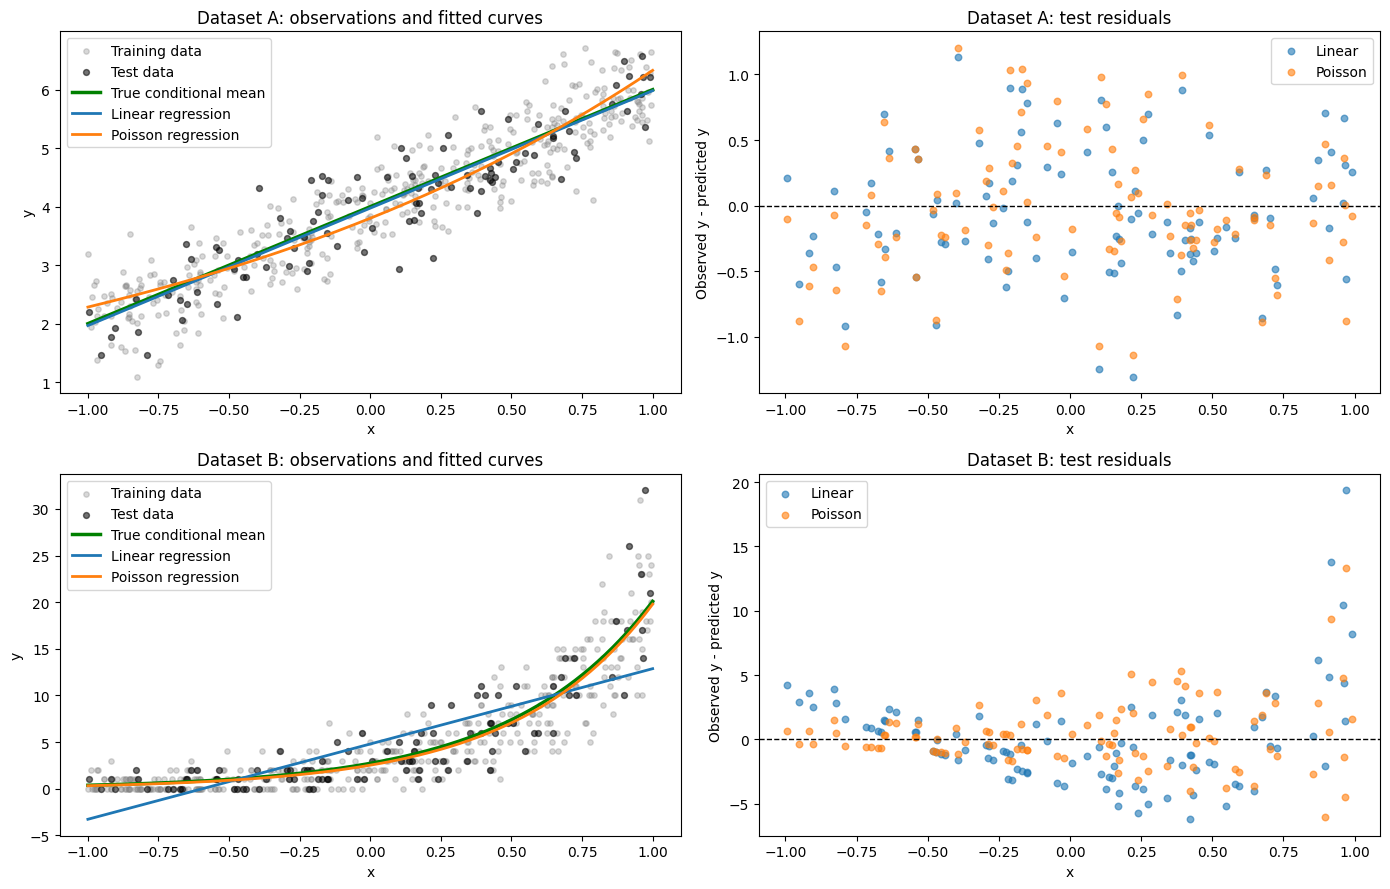

In [2]:
# ============================================================
# HW1-problem2.1
#same imput variables x로 Dataset A와 B를 만들고
#Linear / Poisson Regression fitting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# 1. 실험 설정 및 공통 입력 x 생성
# ------------------------------------------------------------

rng = np.random.default_rng(0)  # 실행할 때마다 매번 같은 데이터 얻기 위한 시드
n_samples = 500 #sample size 500
sigma = 0.5 # noise 분포

# x: (500, 1)
# Dataset A, DatasetB는 같은 x 사용.
x = rng.uniform(-1, 1, size=(n_samples, 1)) # 균등분포 정의
x_values = x[:, 0]

# ------------------------------------------------------------
# 2. Dataset A Generation: LInear+ noise
#    y_A = beta0_A + beta_A * x + epsilon
# ------------------------------------------------------------

beta0_A = 4.0
beta_A = 2.0

epsilon = rng.normal(loc=0, scale=sigma, size=n_samples)
y_A = beta0_A + beta_A * x_values + epsilon

# 푸아송 회귀는 음수 타깃을 받을 수 있으므로 이를 확인한다.
# 현재 설정과 시드에서는 음수가 나오지 않아야 한다.
assert np.all(y_A >= 0), "Dataset A에 음수 y가 생성되었습니다."

# ------------------------------------------------------------
# 3. Dataset B Generation: Poisson
#    log(lambda) = beta0_B + beta_B * x
#    y_B ~ Poisson(lambda)
# ------------------------------------------------------------

beta0_B = 1.0
beta_B = 2.0

lambda_B = np.exp(beta0_B + beta_B * x_values)
y_B = rng.poisson(lam=lambda_B)

# Data generation 결과 확인 (일부)
print("=== 생성된 데이터: 처음 10개 ===")
display(pd.DataFrame({
    "x (shared)": x_values,
    "y_A (linear generation)": y_A,
    "lambda_B (Poisson mean)": lambda_B,
    "y_B (Poisson generation)": y_B,
}).head(10).round(3))

print(f"Dataset A의 y 범위: {y_A.min():.3f} ~ {y_A.max():.3f}")
print(f"Dataset B의 y 범위: {y_B.min()} ~ {y_B.max()}")

# ------------------------------------------------------------
# 4. Training / Test 데이터 분할
# ------------------------------------------------------------

all_indices = np.arange(n_samples)

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# 5. 총 4개 model fitting 및 결과
# ------------------------------------------------------------

datasets = {"A": y_A, "B": y_B}
fitted_models = {}
result_rows = []

for dataset_name, y in datasets.items():

    # 같은 dataset+ 다른 regression model 학습
    model_candidates = {
        "Linear": LinearRegression(),
        "Poisson": PoissonRegressor(alpha=0, max_iter=2000),
    }

    for model_name, model in model_candidates.items():
        model.fit(x[train_idx], y[train_idx])
        fitted_models[(dataset_name, model_name)] = model

        # Test data로 성능 확인
        y_pred = model.predict(x[test_idx])

        mae = mean_absolute_error(y[test_idx], y_pred)
        rmse = np.sqrt(mean_squared_error(y[test_idx], y_pred))

        result_rows.append({
            "Dataset": dataset_name,
            "Fitted model": model_name,
            "Estimated beta0": model.intercept_,
            "Estimated beta": model.coef_[0],
            "Test MAE": mae,
            "Test RMSE": rmse,
            "Negative predictions": np.sum(y_pred < 0),
        })

print("\n=== 실제 데이터 생성 계수 ===")
print(f"Dataset A: beta0 = {beta0_A}, beta = {beta_A}, sigma = {sigma}")
print(f"Dataset B: beta0 = {beta0_B}, beta = {beta_B}")

print("\n=== 네 가지 피팅 결과 ===")
results_df = pd.DataFrame(result_rows)
display(results_df.round(3))

# ------------------------------------------------------------
# 6. 그래프: data,예측 곡선, 잔차
# ------------------------------------------------------------

# 매끄러운 곡선을 그리기 위한 x값
x_plot = np.linspace(-1, 1, 300).reshape(-1, 1)
x_plot_values = x_plot[:, 0]

# 각 데이터 생성 방식의 '진짜 평균'
# A: E[y_A | x] = beta0_A + beta_A*x
# B: E[y_B | x] = lambda_B = exp(beta0_B + beta_B*x)
true_mean = {
    "A": beta0_A + beta_A * x_plot_values,
    "B": np.exp(beta0_B + beta_B * x_plot_values),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, dataset_name in enumerate(["A", "B"]):
    y = datasets[dataset_name]
    linear_model = fitted_models[(dataset_name, "Linear")]
    poisson_model = fitted_models[(dataset_name, "Poisson")]

    # 왼쪽 그래프: 실제 데이터와 두 모델의 예측 곡선
    ax = axes[row, 0]

    ax.scatter(
        x[train_idx, 0], y[train_idx],
        color="gray", s=15, alpha=0.3, label="Training data"
    )
    ax.scatter(
        x[test_idx, 0], y[test_idx],
        color="black", s=18, alpha=0.55, label="Test data"
    )

    ax.plot(
        x_plot_values, true_mean[dataset_name],
        color="green", linewidth=2.5, label="True conditional mean"
    )
    ax.plot(
        x_plot_values, linear_model.predict(x_plot),
        color="tab:blue", linewidth=2, label="Linear regression"
    )
    ax.plot(
        x_plot_values, poisson_model.predict(x_plot),
        color="tab:orange", linewidth=2, label="Poisson regression"
    )

    ax.set_title(f"Dataset {dataset_name}: observations and fitted curves")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    # 오른쪽 그래프: 테스트 데이터의 잔차
    # 잔차 = 실제 y - predicted_ y
    ax = axes[row, 1]

    for model_name, color in [
        ("Linear", "tab:blue"),
        ("Poisson", "tab:orange"),
    ]:
        model = fitted_models[(dataset_name, model_name)]
        predictions = model.predict(x[test_idx])
        residuals = y[test_idx] - predictions

        ax.scatter(
            x[test_idx, 0], residuals,
            color=color, s=22, alpha=0.6, label=model_name
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Dataset {dataset_name}: test residuals")
    ax.set_xlabel("x")
    ax.set_ylabel("Observed y - predicted y")
    ax.legend()

plt.tight_layout()
fig.savefig("regression_plots.png", dpi=200, bbox_inches="tight")
plt.show()

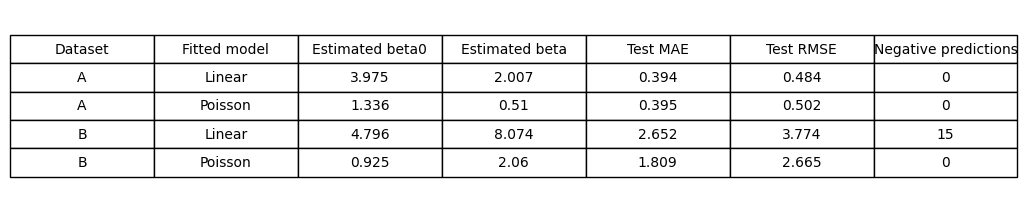

In [3]:
# 기존 코드에서 만든 results_df를 이미지 표로 저장
table_data = results_df.round(3)

fig_table, ax = plt.subplots(figsize=(13, 2.5))
ax.axis("off")

table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.7)

fig_table.savefig("regression_results_table.png",
                  dpi=200, bbox_inches="tight")
plt.show()

In [4]:
from google.colab import files

files.download("regression_plots.png")
files.download("regression_results_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>